# ۴.۶ و ۴.۷ — خوشه‌بندی/کشف الگو و توازن/پوشش/کفایت داده

**بندهای WBS:** ۴.۶ (خوشه‌بندی سلف‌ها/غذاها، کاهش بعد، تصمیم استراتژیک Global/per-cluster/per-restaurant) و ۴.۷ (توازن، پوشش و کفایت داده) — فاز ۴ (کاوش اکتشافی داده).

**داده:** `data/processed/dataset_v1.csv` (فقط‌خواندنی، snapshot قفل‌شده‌ی M1) — سطح (روز d، وعده m، سلف r، غذا f)، ۷٬۵۹۱ ردیف، ۳۲ سلف، ۷۸ غذا، بازه‌ی ۱۴۰۲-۰۹-۰۱ تا ۱۴۰۳-۰۳-۰۱ (۱۴۲ روز سرو‌شده).

**ترتیب اجرا در این نوت‌بوک** (کمی متفاوت از شماره‌گذاری WBS): ابتدا ۴.۶.۱ تا ۴.۶.۳ (خوشه‌بندی سلف، خوشه‌بندی غذا، کاهش بعد)، سپس ۴.۷ (پوشش/کفایت داده)، و در پایان **۴.۶.۴** (تصمیم استراتژیک Global/per-cluster/per-restaurant) به‌عنوان جمع‌بندی — چون این تصمیم صریحاً به شواهد کمّی بند ۴.۷ (تعداد نمونه‌ی هر سلف/سری) نیاز دارد و منطقی است پس از آن‌ها نوشته شود.

**محدودیت نصب:** `tslearn` و `umap-learn` نصب نیستند (طبق دستور پروژه نباید pip install شوند) — به‌جای DTW-clustering و UMAP از ویژگی‌های آماری + PCA/t-SNE استاندارد `scikit-learn` استفاده می‌شود.


In [1]:
import sys
sys.path.insert(0, '/home/mvajhi/code/new_project')

from src.config import set_global_seed, DATA_PROCESSED, FIGURES_DIR
set_global_seed()

from src.viz_fa import setup, fa
setup()

from src.eda_lib.univariate_helpers import save_fig
from src.eda_lib.clustering_helpers import (
    restaurant_feature_matrix, food_feature_matrix, cluster_quality_scan,
    coverage_matrix, series_length_distribution, relative_week_index,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

RNG = 42


In [2]:
df = pd.read_csv(DATA_PROCESSED / 'dataset_v1.csv')
df['date_gregorian'] = pd.to_datetime(df['date_gregorian'])
print(df.shape)
print('restaurants:', df.RestaurantName.nunique(), '| foods:', df.FoodName.nunique())
print('date range:', df.date_gregorian.min().date(), '..', df.date_gregorian.max().date())
df.head(3)


(7591, 22)
restaurants: 32 | foods: 78
date range: 2023-11-22 .. 2024-05-21


,DateReserve,date_gregorian,Meal,RestaurantName,RestaurantType,FoodName,FoodType,Res,Recv,NoRecv,gender_ratio,card_ratio,DayOfWeek,HolidayInWeekCount,HolidayInPrevWeekCount,HolidayInNextWeekCount,NextHoliday_1,NextHoliday_2,PreviousHoliday_1,PreviousHoliday_2,rho,is_served
0,1402-09-01,2023-11-22,dinner,ابوریحان,daneshgah,خوراک سالاد الویه,khorak,60.0,59.0,1.0,0.700000,0.915254,4,0,0,0,25,81,50,59,0.016667,True
1,1402-09-01,2023-11-22,dinner,ابوریحان,daneshgah,چلوکباب تابه ای,berenji,96.0,93.0,3.0,0.302083,0.978495,4,0,0,0,25,81,50,59,0.031250,True
2,1402-09-01,2023-11-22,dinner,ساختمان 6,khabgah,خوراک سالاد الویه,khorak,262.0,245.0,17.0,0.000000,0.897959,4,0,0,0,25,81,50,59,0.064885,True


## ۴.۶.۱ خوشه‌بندی سلف‌ها بر اساس پروفایل رفتاری

بردار ویژگی هر سلف: میانگین/انحراف‌معیار $\rho$، پروفایل هفتگی نرمال‌شده (۷ روز)، تفاوت ناهار−شام، پرچم دو-وعده‌بودن، میانگین $\log(1+Res)$، و شیب روند زمانی $\rho$. ساخته‌شده با `restaurant_feature_matrix` (`src/eda_lib/clustering_helpers.py`).


In [3]:
rfm = restaurant_feature_matrix(df)
print(rfm.shape)
print('\nNaN count per column:')
print(rfm.isna().sum()[rfm.isna().sum() > 0])
rfm.sort_values('n_obs').head(5)[['restaurant_type', 'n_obs', 'total_res', 'mean_rho', 'serves_both_meals']]


(32, 16)

NaN count per column:
dow_0                 2
dow_1                 2
dow_2                 2
dow_3                 2
dow_4                 2
dow_5                19
dow_6                21
lunch_dinner_diff    21
dtype: int64


,restaurant_type,n_obs,total_res,mean_rho,serves_both_meals
RestaurantName,,,,,
دوره حوزه علوم انسانی,daneshgah,5,79.0,0.101008,0
دوره حوزه علوم انسانی ( مهر),daneshgah,7,124.0,0.496769,0
کارآفرینی,daneshgah,142,3297.0,0.176934,0
مطالعات جهان,daneshgah,155,3012.0,0.120448,0
زبانهای خارجه,daneshgah,186,24457.0,0.109584,0


**دو نکته‌ی روش‌شناختی قبل از خوشه‌بندی:**

1. **مقادیر گمشده واقعی‌اند، نه خطا.** بسیاری از سلف‌های `daneshgah` فقط روزهای کاری (شنبه–چهارشنبه) باز هستند، پس `dow_5`/`dow_6` (پنجشنبه/جمعه) برایشان تعریف‌نشده است — نه صفرِ واقعی. این مقادیر با ۱٫۰ (خنثی/بدون انحراف از میانگین سلف) پر می‌شوند تا کورکورانه به سمت «بسیار پایین‌تر از میانگین» متمایل نشوند. مشابه آن، ۲۱ از ۳۲ سلف فقط یک وعده سرو می‌کنند → `lunch_dinner_diff` آن‌ها NaN است و با ۰ (خنثی) پر می‌شود؛ پرچم `serves_both_meals` این حالت را برای تفسیر دستی جدا نگه می‌دارد.
2. **دو سلف با نمونه‌ی بسیار کوچک** («دوره حوزه علوم انسانی» با ۵ رکورد و نسخه‌ی «(مهر)» آن با ۷ رکورد) در ماتریس ویژگی می‌مانند اما برآورد `mean_rho`/`trend_slope`شان به‌شدت نویزی است (این دقیقاً یکی از شواهد بند ۴.۷ برای عدم کفایت مدل per-restaurant).


In [4]:
dow_cols = [f'dow_{d}' for d in range(7)]
FEATURE_COLS = ['mean_rho', 'std_rho'] + dow_cols + ['lunch_dinner_diff', 'serves_both_meals', 'log_res_mean', 'trend_slope']

rfm_filled = rfm.copy()
rfm_filled[dow_cols] = rfm_filled[dow_cols].fillna(1.0)
rfm_filled['lunch_dinner_diff'] = rfm_filled['lunch_dinner_diff'].fillna(0.0)

X_rest_raw = rfm_filled[FEATURE_COLS].to_numpy()
scaler_rest = StandardScaler()
X_rest = scaler_rest.fit_transform(X_rest_raw)
print('feature matrix for clustering:', X_rest.shape, '(n_restaurants x n_features)')
print('features:', FEATURE_COLS)


feature matrix for clustering: (32, 13) (n_restaurants x n_features)
features: ['mean_rho', 'std_rho', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6', 'lunch_dinner_diff', 'serves_both_meals', 'log_res_mean', 'trend_slope']


In [5]:
quality_rest = cluster_quality_scan(X_rest, range(2, 11), random_state=RNG)
quality_rest


,k,inertia,silhouette,davies_bouldin
0,2,323.796741,0.557037,0.307170
1,3,250.132089,0.233051,1.228231
2,4,205.663258,0.233052,1.074475
3,5,170.184896,0.188809,1.089120
4,6,145.563620,0.188358,0.975893
5,7,127.493097,0.190494,0.768208
6,8,108.415851,0.179450,0.915628
7,9,93.833761,0.185446,0.821781
8,10,82.696290,0.161518,0.811859


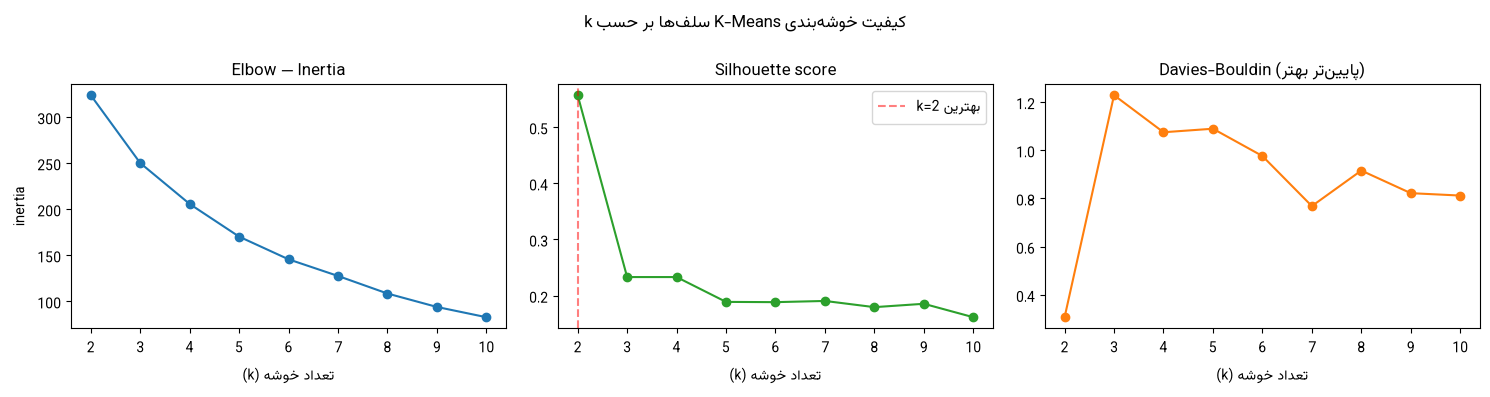

بهترین k بر اساس Silhouette: 2 (score=0.557)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(quality_rest['k'], quality_rest['inertia'], 'o-')
axes[0].set_title(fa('Elbow — Inertia'))
axes[0].set_xlabel(fa('تعداد خوشه (k)'))
axes[0].set_ylabel('inertia')

axes[1].plot(quality_rest['k'], quality_rest['silhouette'], 'o-', color='tab:green')
axes[1].set_title(fa('Silhouette score'))
axes[1].set_xlabel(fa('تعداد خوشه (k)'))
best_k_sil = int(quality_rest.loc[quality_rest['silhouette'].idxmax(), 'k'])
axes[1].axvline(best_k_sil, color='red', ls='--', alpha=0.5, label=fa(f'بهترین k={best_k_sil}'))
axes[1].legend()

axes[2].plot(quality_rest['k'], quality_rest['davies_bouldin'], 'o-', color='tab:orange')
axes[2].set_title(fa('Davies-Bouldin (پایین‌تر بهتر)'))
axes[2].set_xlabel(fa('تعداد خوشه (k)'))

fig.suptitle(fa('کیفیت خوشه‌بندی K-Means سلف‌ها بر حسب k'))
fig.tight_layout()
save_fig(fig, '4.6_restaurant_kmeans_quality.png', FIGURES_DIR)
plt.show()

print(f'بهترین k بر اساس Silhouette: {best_k_sil} (score={quality_rest["silhouette"].max():.3f})')


In [7]:
km_rest = KMeans(n_clusters=best_k_sil, random_state=RNG, n_init=20)
rfm_filled['kmeans_cluster'] = km_rest.fit_predict(X_rest)

print(fa('تعداد سلف در هر خوشه:'))
print(rfm_filled['kmeans_cluster'].value_counts().sort_index())
print()
print(fa('نوع سلف بر حسب خوشه (crosstab):'))
print(pd.crosstab(rfm_filled['kmeans_cluster'], rfm_filled['restaurant_type']))
print()
cluster_summary = rfm_filled.groupby('kmeans_cluster')[['mean_rho', 'std_rho', 'log_res_mean', 'trend_slope', 'n_obs', 'serves_both_meals']].mean()
cluster_summary


ﺗﻌﺪﺍﺩ ﺳﻠﻒ ﺩﺭ ﻫﺮ ﺧﻮﺷﻪ:
kmeans_cluster
0    31
1     1
Name: count, dtype: int64

ﻧﻮﻉ ﺳﻠﻒ ﺑﺮ ﺣﺴﺐ ﺧﻮﺷﻪ (crosstab):
restaurant_type  daneshgah  khabgah
kmeans_cluster                     
0                       21       10
1                        1        0



,mean_rho,std_rho,log_res_mean,trend_slope,n_obs,serves_both_meals
kmeans_cluster,,,,,,
0,0.104184,0.075666,4.742687,0.000034,244.645161,0.354839
1,0.496769,0.478583,2.900878,0.003176,7.000000,0.000000


In [8]:
for c in sorted(rfm_filled['kmeans_cluster'].unique()):
    members = rfm_filled[rfm_filled['kmeans_cluster'] == c].sort_values('mean_rho')
    print(f'--- cluster {c} (n={len(members)}) ---')
    print(members[['restaurant_type', 'n_obs', 'mean_rho', 'serves_both_meals']].to_string())
    print()


--- cluster 0 (n=31) ---
                               restaurant_type  n_obs  mean_rho  serves_both_meals
RestaurantName                                                                    
فومن                                   khabgah    333  0.039134                  1
کاسپین                                 khabgah    314  0.039896                  1
ابوریحان                             daneshgah    450  0.049738                  1
سطح شهر                                khabgah    310  0.049765                  1
فارابی                                 khabgah    479  0.069765                  1
کشاورزی                                khabgah    337  0.072911                  1
ساختمان 6                              khabgah    258  0.075405                  1
فنی امیرآباد                         daneshgah    198  0.078913                  0
کوی                                    khabgah    480  0.086033                  1
فاطمیه                                 khabgah    480  0.08951

### خوشه‌بندی سلسله‌مراتبی Ward + دندروگرام

طبق هشدار WBS، با فقط ۳۲ سلف خوشه‌بندی الگوریتمی می‌تواند بی‌ثبات باشد — دندروگرام کامل به همراه برچسب نام سلف نگاه دقیق‌تری از ساختار سلسله‌مراتبی می‌دهد و امکان تفسیر دستی را فراهم می‌کند.


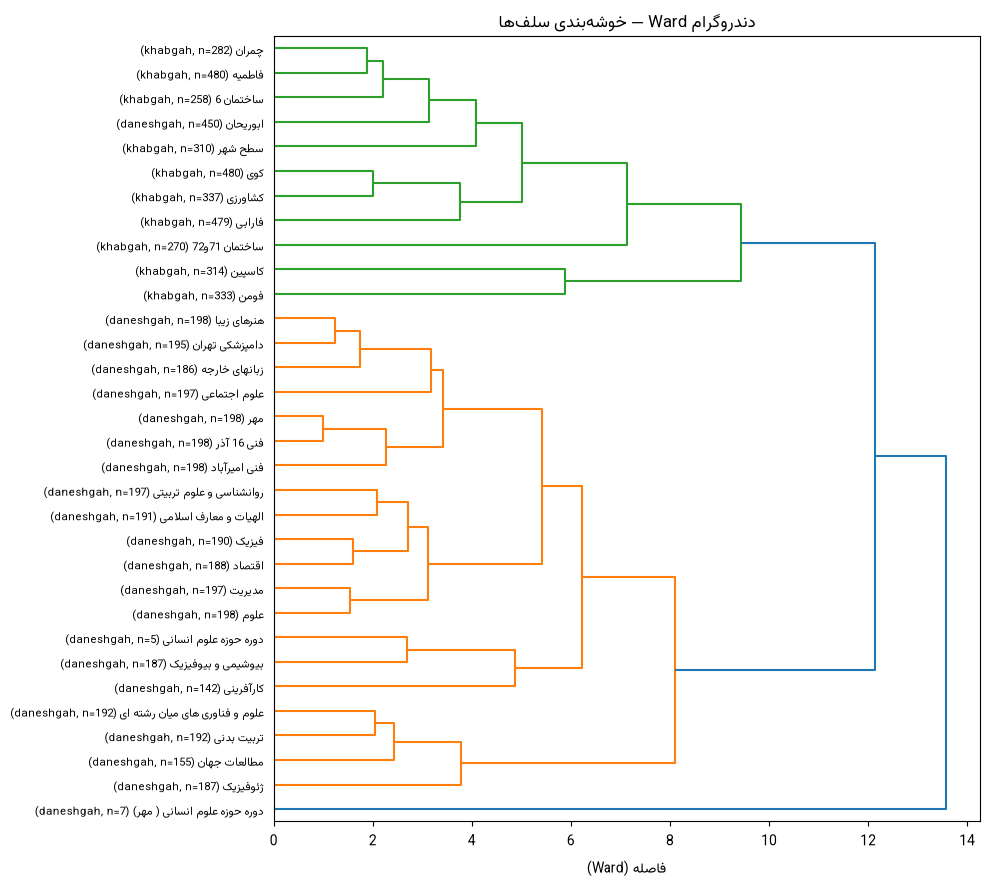

توافق K-Means vs Ward (برش در همان k=2) — Adjusted Rand Index: 1.000
ward     1  2
kmeans       
0       31  0
1        0  1


In [9]:
Z_rest = linkage(X_rest, method='ward')

fig, ax = plt.subplots(figsize=(10, 9))
labels_fa = [fa(f'{name} ({rfm_filled.loc[name, "restaurant_type"]}, n={rfm_filled.loc[name, "n_obs"]})') for name in rfm_filled.index]
dendrogram(Z_rest, labels=labels_fa, orientation='right', color_threshold=0.7 * max(Z_rest[:, 2]), ax=ax)
ax.set_title(fa('دندروگرام Ward — خوشه‌بندی سلف‌ها'))
ax.set_xlabel(fa('فاصله (Ward)'))
fig.tight_layout()
save_fig(fig, '4.6_restaurant_dendrogram.png', FIGURES_DIR)
plt.show()

ward_labels = fcluster(Z_rest, t=best_k_sil, criterion='maxclust')
rfm_filled['ward_cluster'] = ward_labels
ari = adjusted_rand_score(rfm_filled['kmeans_cluster'], rfm_filled['ward_cluster'])
print(f'توافق K-Means vs Ward (برش در همان k={best_k_sil}) — Adjusted Rand Index: {ari:.3f}')
print(pd.crosstab(rfm_filled['kmeans_cluster'], rfm_filled['ward_cluster'], rownames=['kmeans'], colnames=['ward']))


**تفسیر دستی خوشه‌ها (TODO — بعد از اجرا با اعداد واقعی تکمیل می‌شود):** به کراس‌تب `restaurant_type` × خوشه، جدول میانگین `mean_rho`/`log_res_mean`/`n_obs` هر خوشه، و ARI بالا نگاه کنید — آیا خوشه‌ها با `RestaurantType` (daneshgah/khabgah) هم‌راستا هستند یا محور دیگری (حجم رزرو، نرخ متوسط) دارند؟

## ۴.۶.۲ خوشه‌بندی غذاها

بردار ویژگی هر غذا (طبق WBS): میانگین $\rho$، تعداد دفعات سرو (لگاریتمی)، و میانگین حجم رزرو نسبی — یعنی $Res$ آن غذا تقسیم‌بر میانگین $Res$ زمینه‌ی (سلف, وعده)ی میزبانش، تا اندازه‌ی ذاتی سلف باعث تورش مقایسه نشود. ساخته‌شده با `food_feature_matrix`.

**⚠️ هشدار نشت از هم‌اکنون:** هر «شاخص محبوبیت غذا» که از این تحلیل بیرون می‌آید فقط برای EDA است. اگر در فاز ۵ به فیچر مدل تبدیل شود، باید برای هر رکورد فقط از تاریخچه‌ی **قبل از لحظه‌ی برش همان رکورد** بازمحاسبه شود (نه از کل بازه‌ی ۵ ماهه مثل اینجا).

In [10]:
ffm = food_feature_matrix(df)
print(ffm.shape)
print('n_served=1 (std_rho تعریف‌نشده):', (ffm['n_served'] == 1).sum())

FOOD_FEATURE_COLS = ['mean_rho', 'log_n_served', 'relative_volume_mean']
ffm_filled = ffm.copy()

X_food_raw = ffm_filled[FOOD_FEATURE_COLS].to_numpy()
scaler_food = StandardScaler()
X_food = scaler_food.fit_transform(X_food_raw)
print('feature matrix:', X_food.shape)
ffm_filled.sort_values('n_served', ascending=False).head(5)


(78, 7)
n_served=1 (std_rho تعریف‌نشده): 7
feature matrix: (78, 3)


,food_type,n_served,mean_rho,std_rho,relative_volume_mean,total_res,log_n_served
FoodName,,,,,,,
چلوجوجه کباب,berenji,379,0.085698,0.090619,1.957453,197861.0,5.940171
چلوکباب کوبیده,berenji,361,0.083024,0.098705,1.666136,179097.0,5.891644
چلو خورش قیمه سیب زمینی,berenji,353,0.088185,0.075906,1.374066,123999.0,5.869297
عدس پلو با گوشت و کشمش,berenji,343,0.103160,0.069341,1.194946,100096.0,5.840642
چلو خورش قورمه سبزی,berenji,337,0.096803,0.090797,1.179800,107670.0,5.823046


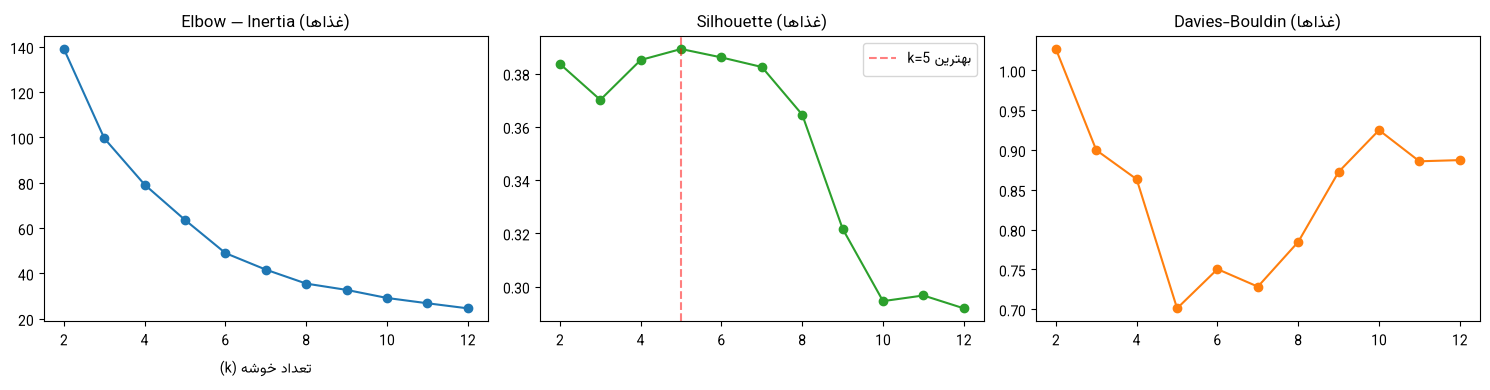

بهترین k غذاها بر اساس Silhouette: 5 (score=0.389)


In [11]:
quality_food = cluster_quality_scan(X_food, range(2, 13), random_state=RNG)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(quality_food['k'], quality_food['inertia'], 'o-')
axes[0].set_title(fa('Elbow — Inertia (غذاها)'))
axes[0].set_xlabel(fa('تعداد خوشه (k)'))

axes[1].plot(quality_food['k'], quality_food['silhouette'], 'o-', color='tab:green')
best_k_food = int(quality_food.loc[quality_food['silhouette'].idxmax(), 'k'])
axes[1].axvline(best_k_food, color='red', ls='--', alpha=0.5, label=fa(f'بهترین k={best_k_food}'))
axes[1].set_title(fa('Silhouette (غذاها)'))
axes[1].legend()

axes[2].plot(quality_food['k'], quality_food['davies_bouldin'], 'o-', color='tab:orange')
axes[2].set_title(fa('Davies-Bouldin (غذاها)'))

fig.tight_layout()
save_fig(fig, '4.6_food_kmeans_quality.png', FIGURES_DIR)
plt.show()
print(f'بهترین k غذاها بر اساس Silhouette: {best_k_food} (score={quality_food["silhouette"].max():.3f})')


In [12]:
km_food = KMeans(n_clusters=best_k_food, random_state=RNG, n_init=20)
ffm_filled['cluster'] = km_food.fit_predict(X_food)

cluster_food_summary = ffm_filled.groupby('cluster').agg(
    n_foods=('mean_rho', 'size'),
    mean_rho=('mean_rho', 'mean'),
    mean_n_served=('n_served', 'mean'),
    mean_relative_volume=('relative_volume_mean', 'mean'),
)
print(cluster_food_summary)
print()
for c in sorted(ffm_filled['cluster'].unique()):
    top = ffm_filled[ffm_filled['cluster'] == c].sort_values('n_served', ascending=False).head(4)
    print(f'cluster {c} — نمونه غذاهای پرتکرار:', list(top.index))


         n_foods  mean_rho  mean_n_served  mean_relative_volume
cluster                                                        
0             27  0.062129      10.703704              0.693568
1             19  0.106255     150.105263              0.491499
2             25  0.091506     177.520000              1.295996
3              6  0.033814       1.833333              1.506027
4              1  0.200000       1.000000              0.076097

cluster 0 — نمونه غذاهای پرتکرار: ['خوراک نودلیت', 'خوراک مرغ و قارچ', 'لوبیا پلو با گوشت', 'ساندویچ همبرگر']
cluster 1 — نمونه غذاهای پرتکرار: ['خوراک آبگوشت', 'خوراک ماکارونی با قارچ', 'خوراک کشک بادمجان', 'خوراک فلافل']
cluster 2 — نمونه غذاهای پرتکرار: ['چلوجوجه کباب', 'چلوکباب کوبیده', 'چلو خورش قیمه سیب زمینی', 'عدس پلو با گوشت و کشمش']
cluster 3 — نمونه غذاهای پرتکرار: ['خوراک گراتن با سبزیجات', 'چلوتن ماهی', 'خوراک کباب کوبیده', 'خوراک ناگت میگو']
cluster 4 — نمونه غذاهای پرتکرار: ['2 خوراک چیکن استروگانوف']


## ۴.۶.۳ کاهش بعد

### (الف) PCA روی فیچرهای عددی سطح رکورد `dataset_v1`

دو دیدگاه جدا: «فیچرهای کاندید» (بدون `Recv`/`NoRecv`/`rho` که مشتق از outcome‌اند و نباید در PCA فیچر ورودی مخلوط شوند) در برابر «همه‌ی ستون‌های عددی» (توصیفی صرف، شامل خروجی‌ها).

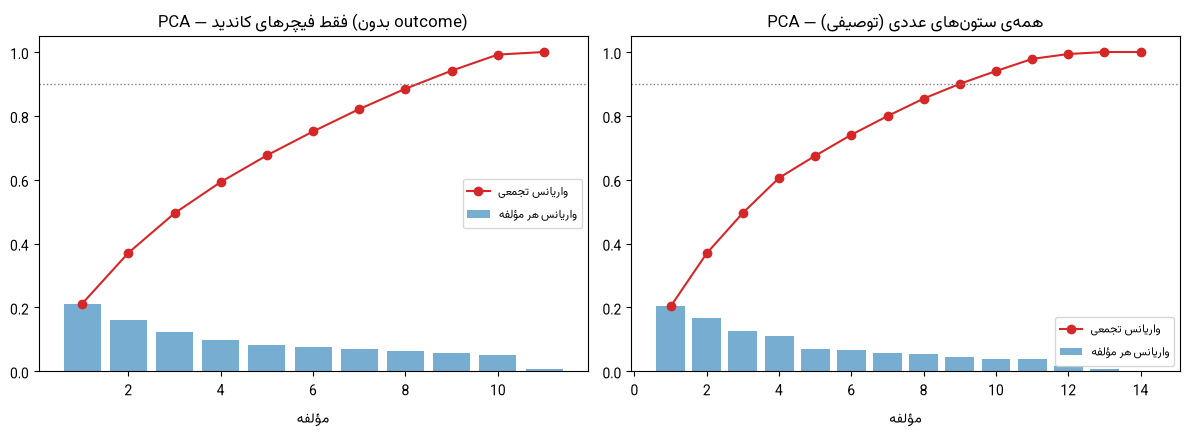

فیچرهای کاندید (11 بعد): 9 مؤلفه برای ۹۰٪ واریانس تجمعی
همه‌ی ستون‌های عددی (14 بعد): 9 مؤلفه برای ۹۰٪ واریانس تجمعی


In [13]:
CANDIDATE_NUM_COLS = ['Res', 'gender_ratio', 'card_ratio', 'DayOfWeek',
                      'HolidayInWeekCount', 'HolidayInPrevWeekCount', 'HolidayInNextWeekCount',
                      'NextHoliday_1', 'NextHoliday_2', 'PreviousHoliday_1', 'PreviousHoliday_2']
FULL_NUM_COLS = CANDIDATE_NUM_COLS + ['Recv', 'NoRecv', 'rho']

def pca_explained_variance(df_, cols, label, ax):
    X = StandardScaler().fit_transform(df_[cols].fillna(0).to_numpy())
    pca = PCA(random_state=RNG).fit(X)
    evr = pca.explained_variance_ratio_
    ax.bar(range(1, len(evr) + 1), evr, alpha=0.6, label=fa('واریانس هر مؤلفه'))
    ax.plot(range(1, len(evr) + 1), np.cumsum(evr), 'o-', color='tab:red', label=fa('واریانس تجمعی'))
    ax.axhline(0.9, color='gray', ls=':', lw=1)
    ax.set_title(fa(label))
    ax.set_xlabel(fa('مؤلفه'))
    ax.legend(fontsize=8)
    n90 = int(np.argmax(np.cumsum(evr) >= 0.9) + 1)
    return pca, n90

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
pca_cand, n90_cand = pca_explained_variance(df, CANDIDATE_NUM_COLS, 'PCA — فقط فیچرهای کاندید (بدون outcome)', axes[0])
pca_full, n90_full = pca_explained_variance(df, FULL_NUM_COLS, 'PCA — همه‌ی ستون‌های عددی (توصیفی)', axes[1])
fig.tight_layout()
save_fig(fig, '4.6_pca_explained_variance.png', FIGURES_DIR)
plt.show()

print(f'فیچرهای کاندید ({len(CANDIDATE_NUM_COLS)} بعد): {n90_cand} مؤلفه برای ۹۰٪ واریانس تجمعی')
print(f'همه‌ی ستون‌های عددی ({len(FULL_NUM_COLS)} بعد): {n90_full} مؤلفه برای ۹۰٪ واریانس تجمعی')


### (ب) PCA و t-SNE برای بصری‌سازی سلف‌ها و غذاها

**هشدار t-SNE:** فقط برای بصری‌سازی — فاصله‌ی بین نقاط در نمودار t-SNE معنای کمّی ندارد و نباید تفسیر شود (فقط مجاورت/گروه‌بندی کیفی). `perplexity` به‌دلیل تعداد کم نمونه (۳۲ سلف) پایین انتخاب شده است.